Dataset shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

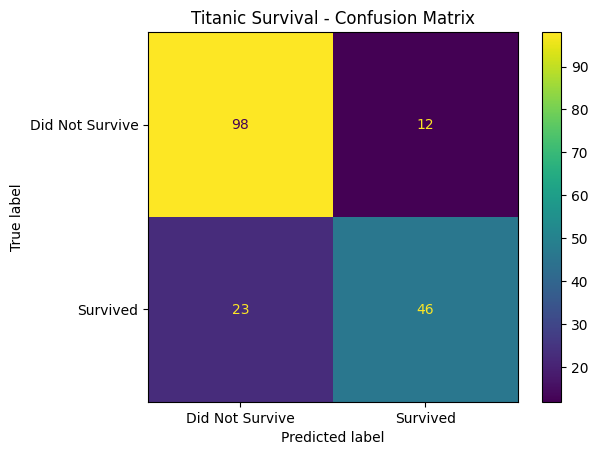

In [5]:
# ============================================
# Titanic Survival Prediction
# Logistic Regression Classification
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# --------------------------------------------
# 1. Load dataset
# --------------------------------------------

with zipfile.ZipFile("titanic.zip", 'r') as z:
    with z.open("train.csv") as f:
        df = pd.read_csv(f)

print("Dataset shape:", df.shape)
print(df.head())

# --------------------------------------------
# 2. Select features and target
# --------------------------------------------

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

# --------------------------------------------
# 3. Encode categorical variables
# --------------------------------------------

X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print("\nEncoded features:")
print(X.head())

# --------------------------------------------
# 4. Handle any remaining missing values
# --------------------------------------------

X = X.fillna(X.median(numeric_only=True))

# --------------------------------------------
# 5. Split data into training and testing sets
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# --------------------------------------------
# 6. Train Logistic Regression model
# --------------------------------------------

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# --------------------------------------------
# 7. Make predictions
# --------------------------------------------

y_pred = model.predict(X_test)

# --------------------------------------------
# 8. Calculate accuracy
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# --------------------------------------------
# 9. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# --------------------------------------------
# 10. Display confusion matrix
# --------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Titanic Survival - Confusion Matrix")
plt.show()